### Imports

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

### Load The Dataset

In [2]:
df = pd.read_csv(r'C:\Users\Aghayeva Duyghu\Desktop\div\project\loan_approval_dataset.csv') # Load dataset from CSV file

In [3]:
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [4]:
print(df[" loan_status"].unique())
print(df[" loan_status"].value_counts())

[' Approved' ' Rejected']
 loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


In [5]:
df.columns = df.columns.str.strip()  # clean column names

df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)  # clean string values

In [6]:
print(df["loan_status"].unique())

['Approved' 'Rejected']


In [7]:
df_copy = df.copy()  # preserve original dataset

In [8]:
df_copy.head() # Display first 5 rows to understand structure

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [9]:
df_copy.info() # Display dataset info (data types, null values)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [10]:
df_copy.describe() # Displays summary statistics of numerical features

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [ ]:
# EDA FUNCTION
def explore_data(df):
    for col in df.columns:
        print(f"\nColumn: {col}")
        print("-"*40)
        
        # Data type
        print("Data type:", df[col].dtype)
        
        # Missing values
        print("Missing values:", df[col].isnull().sum())
        
        # Number of unique values
        print("Unique values:", df[col].nunique())
        
        # Top 10 values
        print("Top 10 value counts:")
        print(df[col].value_counts().head(10))

# Run function
explore_data(df_copy)

### Data Cleaning

In [11]:
# Drop ID column
df_copy.drop("loan_id", axis=1, inplace=True)

# Encode target variable
df_copy["loan_status"] = df_copy["loan_status"].map({"Approved":1, "Rejected":0})

# Encode categorical features
df_copy["education"] = df_copy["education"].map({"Graduate":1, "Not Graduate":0})
df_copy["self_employed"] = df_copy["self_employed"].map({"Yes":1, "No":0})

### Target Analysis

In [12]:
target_counts = df_copy["loan_status"].value_counts()
target_pct = df_copy["loan_status"].value_counts(normalize=True) * 100

print("Counts:\n", target_counts)
print("\nPercentage:\n", target_pct)

Counts:
 loan_status
1    2656
0    1613
Name: count, dtype: int64

Percentage:
 loan_status
1    62.215976
0    37.784024
Name: proportion, dtype: float64


### Feature vs Target Analysis

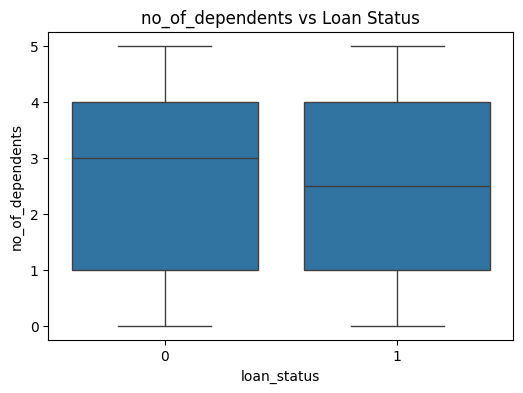

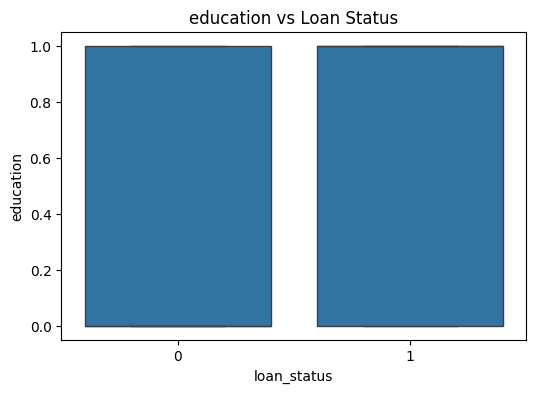

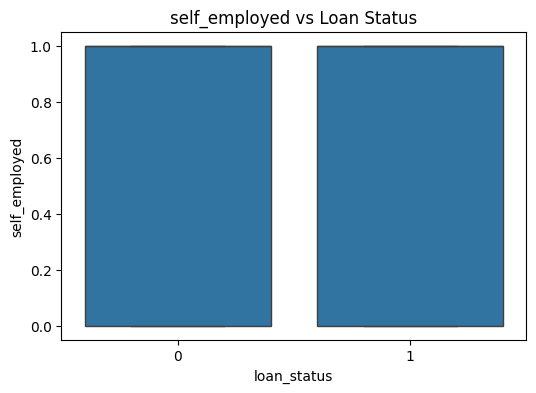

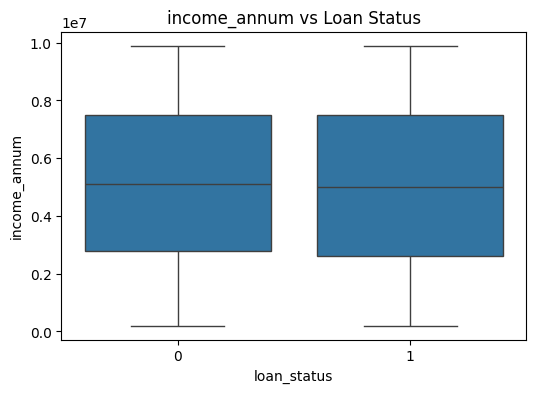

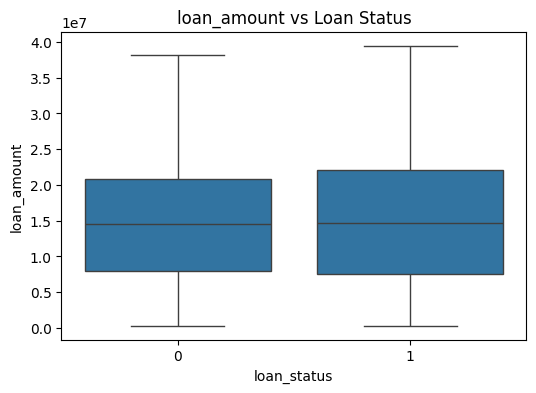

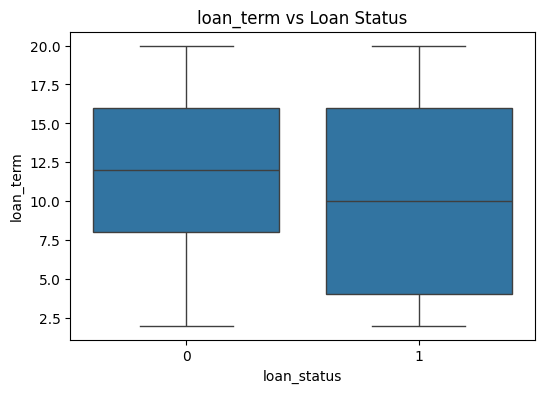

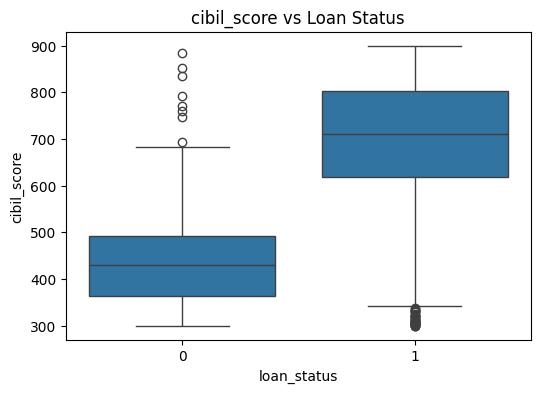

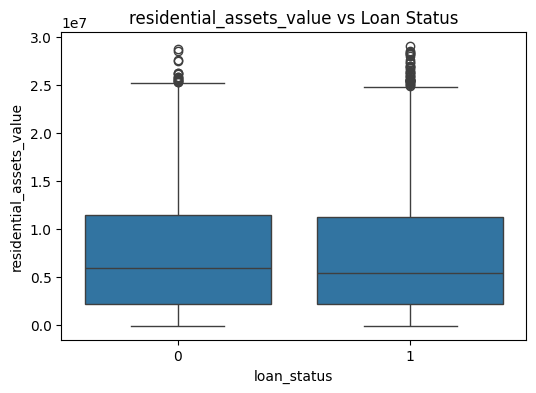

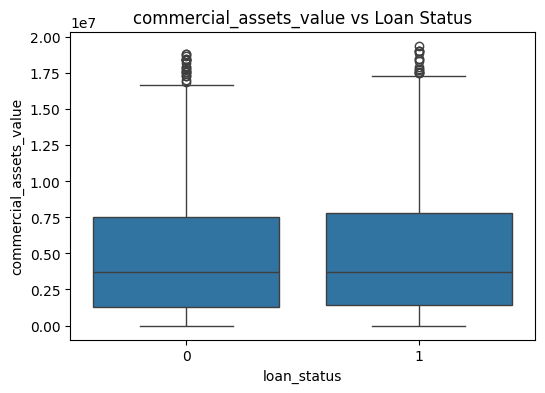

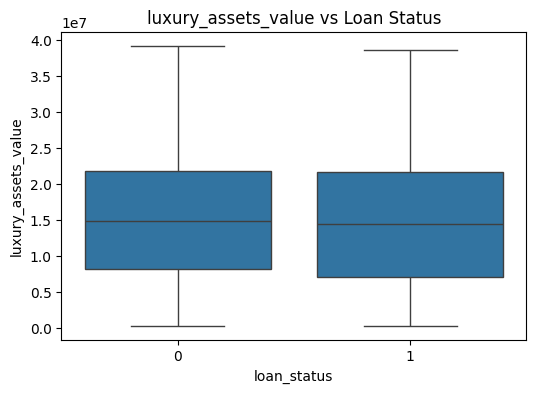

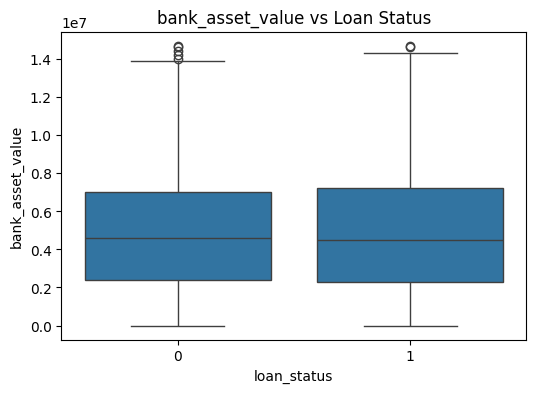

In [13]:
num_cols = df_copy.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    if col != "loan_status":
        plt.figure(figsize=(6,4))
        sns.boxplot(x="loan_status", y=col, data=df_copy)
        plt.title(f"{col} vs Loan Status")
        plt.show()

In [14]:
# GROUPED STATISTICS
grouped_stats = df_copy.groupby("loan_status").mean()

print(grouped_stats)

             no_of_dependents  education  self_employed  income_annum  \
loan_status                                                             
0                    2.538128   0.499070       0.503410  5.113825e+06   
1                    2.474774   0.504142       0.503765  5.025904e+06   

              loan_amount  loan_term  cibil_score  residential_assets_value  \
loan_status                                                                   
0            1.494606e+07  11.728456   429.468072              7.592498e+06   
1            1.524725e+07  10.397590   703.461973              7.399812e+06   

             commercial_assets_value  luxury_assets_value  bank_asset_value  
loan_status                                                                  
0                       4.926720e+06         1.530694e+07      5.004960e+06  
1                       5.001355e+06         1.501660e+07      4.959526e+06  


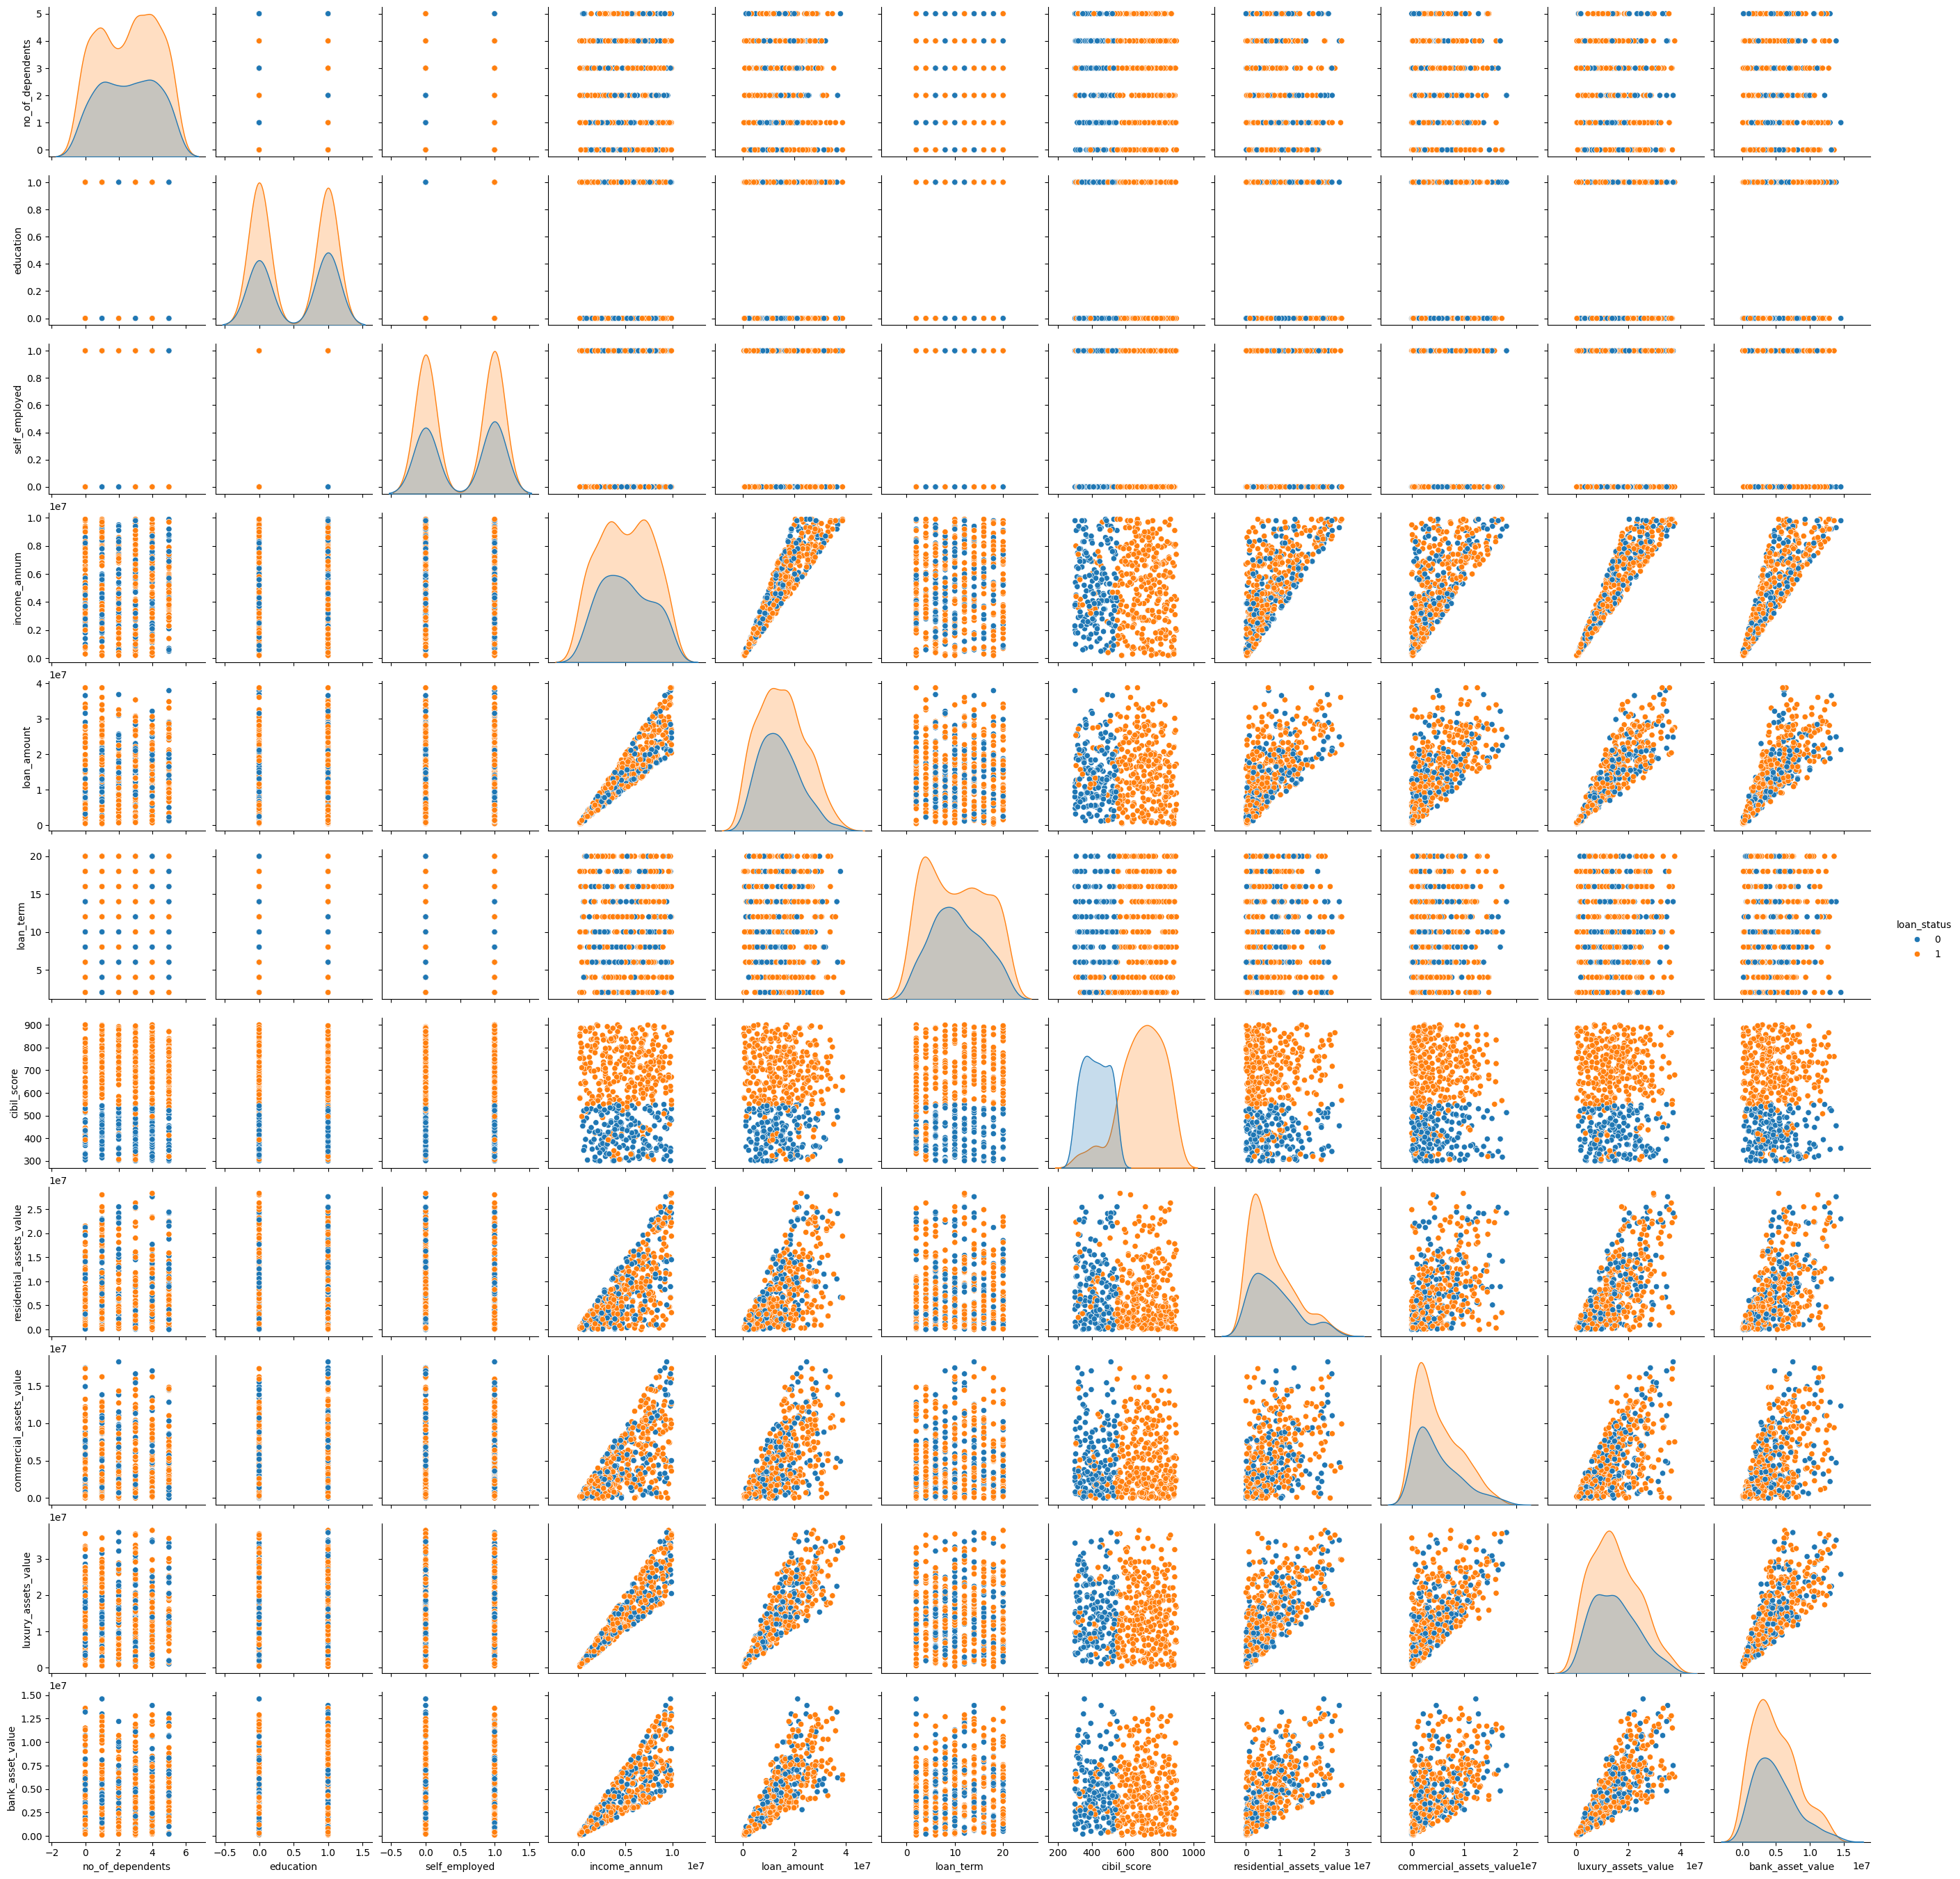

In [15]:
# Pairplot
sns.pairplot(df_copy.sample(500), hue="loan_status")
plt.show()

### Outlier Handling

In [16]:
num_cols = df_copy.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    if col != "loan_status":
        
        Q1 = df_copy[col].quantile(0.25)
        Q3 = df_copy[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        # Cap outliers
        df_copy[col] = np.where(df_copy[col] < lower, lower,
                               np.where(df_copy[col] > upper, upper, df_copy[col]))

### Feature Engineering

In [17]:
# Loan to income ratio
df_copy["loan_to_income"] = df_copy["loan_amount"] / df_copy["income_annum"]

# Total assets
df_copy["total_assets"] = (
    df_copy["residential_assets_value"] +
    df_copy["commercial_assets_value"] +
    df_copy["luxury_assets_value"] +
    df_copy["bank_asset_value"]
)

In [18]:
# Log transform (reduce skewness)
df_copy["income_log"] = np.log1p(df_copy["income_annum"])
df_copy["loan_amount_log"] = np.log1p(df_copy["loan_amount"])

In [19]:
from sklearn.model_selection import train_test_split

X = df_copy.drop("loan_status", axis=1)
y = df_copy["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Scaling

In [20]:
num_cols = X_train.select_dtypes(include=np.number).columns

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

### Correlation Heatmap

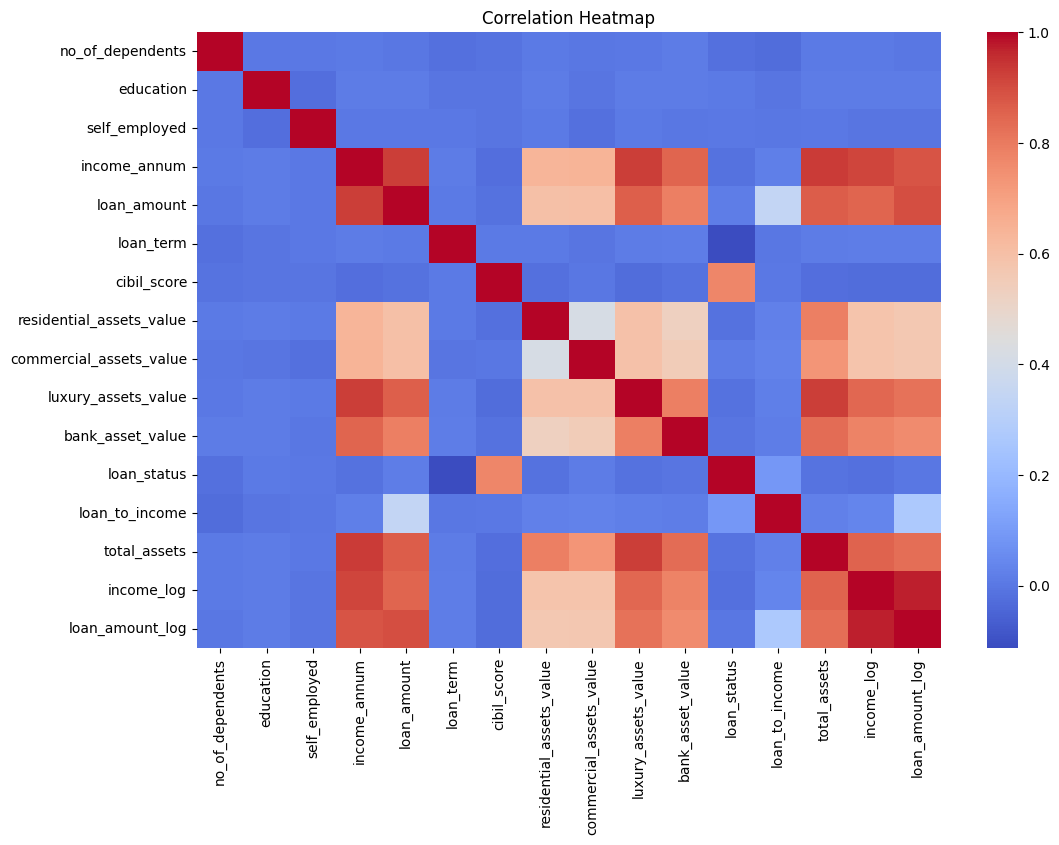

In [22]:
plt.figure(figsize=(12,8))

corr = df_copy.corr()

sns.heatmap(corr, annot=False, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

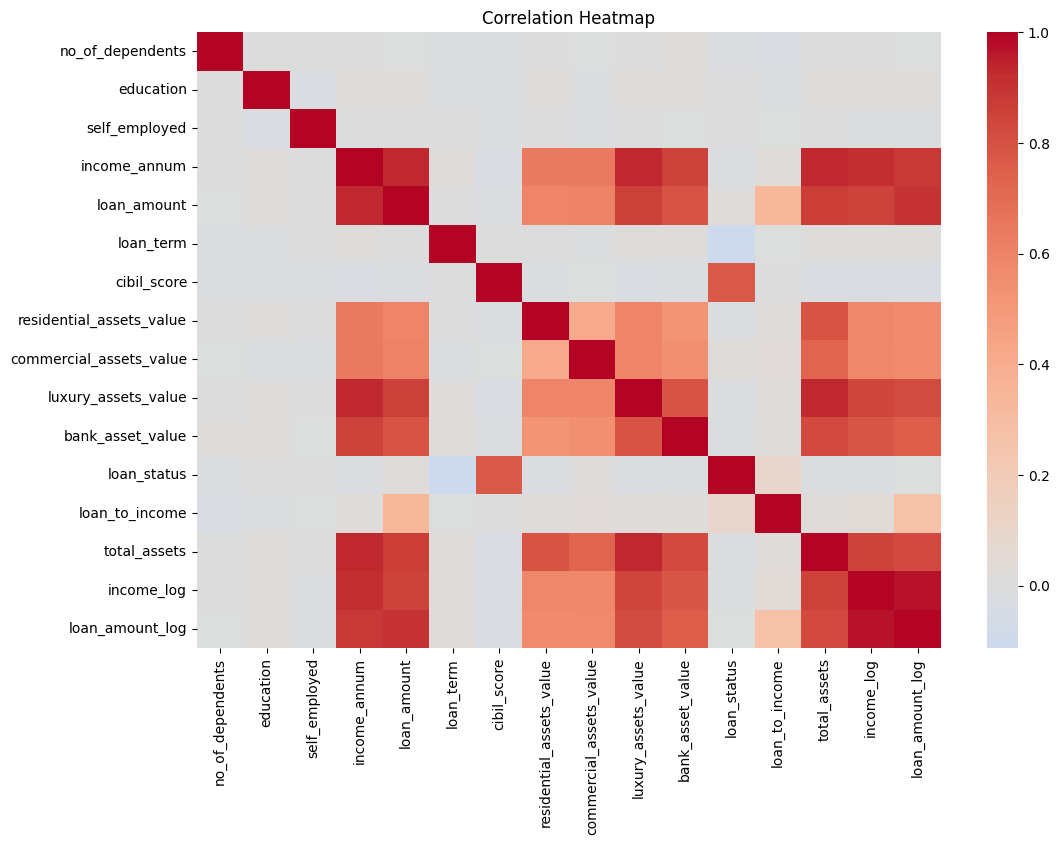

In [23]:
# Focus on strongest correlations
plt.figure(figsize=(12,8))

sns.heatmap(df_copy.corr(), cmap="coolwarm", center=0)

plt.title("Correlation Heatmap")
plt.show()

In [24]:
corr_with_target = df_copy.corr(numeric_only=True)["loan_status"].sort_values()

print(corr_with_target)

loan_term                  -0.113036
income_log                 -0.021659
no_of_dependents           -0.018114
luxury_assets_value        -0.015465
income_annum               -0.015189
residential_assets_value   -0.014985
total_assets               -0.011360
bank_asset_value           -0.006746
loan_amount_log            -0.000332
self_employed               0.000345
education                   0.004918
commercial_assets_value     0.008799
loan_amount                 0.016150
loan_to_income              0.087726
cibil_score                 0.770518
loan_status                 1.000000
Name: loan_status, dtype: float64


In [25]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

num_features = X.select_dtypes(include=np.number).columns
cat_features = X.select_dtypes(exclude=np.number).columns

num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_transformer, num_features),
    ("cat", cat_transformer, cat_features)
])

pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()

In [27]:
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"{name} Accuracy:", accuracy_score(y_test, y_pred))

Logistic Regression Accuracy: 0.8981264637002342
Decision Tree Accuracy: 0.9964871194379391
Random Forest Accuracy: 0.9988290398126464


In [29]:
# Cross Validation
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(f"{name} CV Score:", scores.mean())

c:\Users\Aghayeva Duyghu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Aghayeva Duyghu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown i

Logistic Regression CV Score: 0.7268667411615157
Decision Tree CV Score: 0.993441524746658
Random Forest CV Score: 0.9960179117098764


### Confusion Matrix

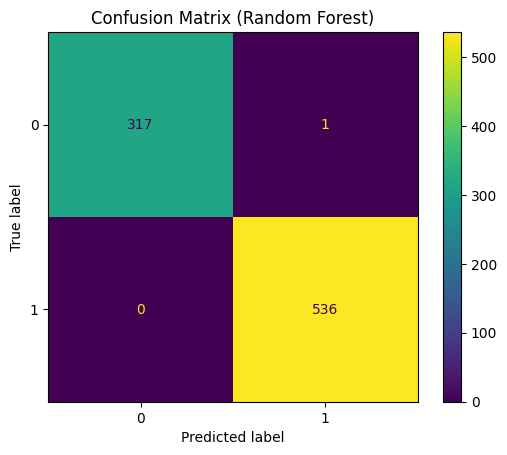

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix (Random Forest)")
plt.show()

### Roc Curve

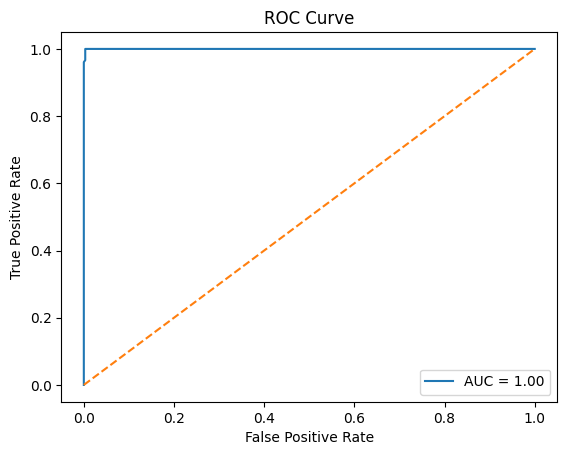

In [31]:
from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

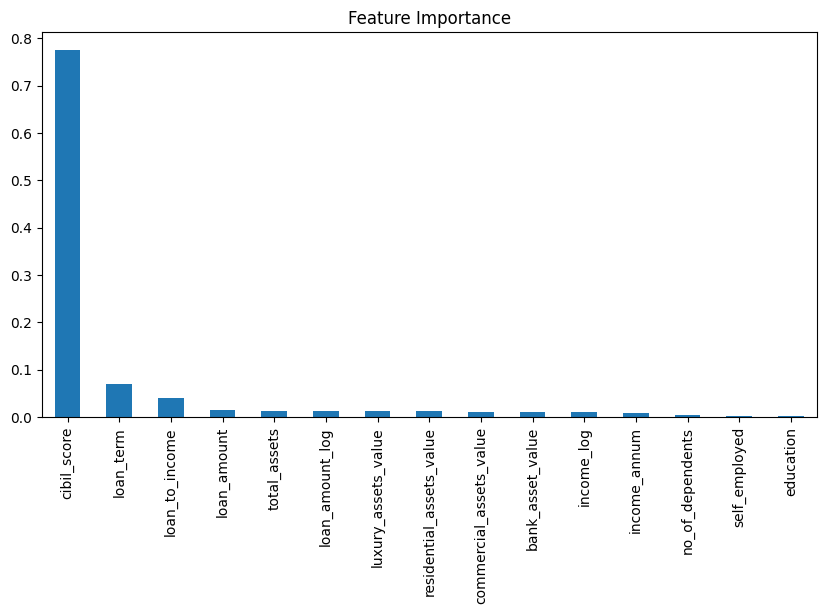

In [32]:
importances = rf.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

feat_imp.plot(kind="bar", figsize=(10,5))
plt.title("Feature Importance")
plt.show()

In [33]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
print("Train Accuracy:", rf.score(X_train, y_train))
print("Test Accuracy:", rf.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.9988290398126464


In [35]:
train_score = pipeline.score(X_train, y_train)
test_score = pipeline.score(X_test, y_test)

print("Train score:", train_score)
print("Test score:", test_score)

Train score: 1.0
Test score: 0.9988290398126464
